# Lecture 3, part 1: Summarize and compare with pivot tables

A retailer sells beauty, household, pet, health, beverage and snack products in 20 stores, in store and online. The data cover 20 weeks, January to May 2025, with one row per sales record. Each record contains one product and the quantity sold. In this notebook you summarize these rows into pivot tables, draw pivot charts from the tables, and turn an exploration chart into a presentation chart. The charts show the same data as the lecture slides, drawn with short code; the slides add formatting for the screen.

The store-performance exercise at the end of the notebook asks you to build your own table and charts.

## 0) Setup and data

Keep this notebook and `L3-retail.csv` in the same folder. Run the cells from top to bottom.

In [1]:
# %pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_context("talk")

## 1.1 Load the data

`L3-retail.csv` has one row per sales record, 95,100 rows in all.

| Column | Meaning |
| --- | --- |
| `date`, `week` | The day of the sale and its week, 1–20. |
| `store_id`, `region` | The store, 1–20, and its region. |
| `store_size`, `rent_tier` | Store characteristics. |
| `channel` | `In-Store` or `Online`. |
| `product_id`, `category`, `brand` | The item sold. |
| `units`, `price`, `discount` | Units sold, list price and discount rate. |
| `revenue` | Revenue from the row, after the discount. |
| `margin` | Revenue minus cost. |

In [2]:
retail = pd.read_csv("L3-retail.csv")
retail.head()

,date,week,store_id,region,store_size,rent_tier,channel,product_id,category,brand,units,price,discount,revenue,margin
0,2025-01-01,1,1,South,Medium,Low,In-Store,93,Beauty,Brand_6,1,13.853216,0.046158,13.213783,6.550809
1,2025-01-01,1,1,South,Medium,Low,In-Store,46,Beauty,Brand_7,1,17.789099,0.038973,17.095813,8.670443
2,2025-01-01,1,1,South,Medium,Low,Online,58,Household,Brand_3,1,9.860400,0.015639,9.706190,4.037873
3,2025-01-01,1,1,South,Medium,Low,Online,113,Household,Brand_17,1,10.680038,0.048040,10.166966,3.552267
4,2025-01-01,1,1,South,Medium,Low,Online,4,Snacks,Brand_17,1,3.321428,0.038520,3.193487,1.047334


## 1.2 A pivot table: revenue by week and channel

A pivot table summarizes one variable across groups. `pivot_table` takes four choices:

- `index`: the variable whose groups become the rows (here `week`);
- `columns`: the variable whose groups become the columns (`channel`);
- `values`: the variable to summarize (`revenue`);
- `aggfunc`: the statistic computed in each cell (`"sum"`).

The 95,100 rows become a table of 20 weeks × 2 channels.

In [3]:
week_channel = retail.pivot_table(index="week", columns="channel", values="revenue", aggfunc="sum")
week_channel.round(0)

channel,In-Store,Online
week,,
1,33026.0,15450.0
2,33705.0,14607.0
3,33874.0,14717.0
4,34761.0,15338.0
5,37236.0,17505.0
6,35298.0,15695.0
7,34798.0,16132.0
8,36144.0,16413.0
9,36578.0,16380.0


`groupby` computes the same sums in long form, one row per week and channel. `unstack()` then moves the channels into columns, which gives the pivot table again.

In [4]:
retail.groupby(["week", "channel"])["revenue"].sum().unstack().round(0).head()

channel,In-Store,Online
week,,
1,33026.0,15450.0
2,33705.0,14607.0
3,33874.0,14717.0
4,34761.0,15338.0
5,37236.0,17505.0


## 1.3 Three kinds of pivot table

A **one-way** table uses one grouping variable: revenue by region.

In [5]:
retail.pivot_table(index="region", values="revenue", aggfunc="sum").sort_values("revenue", ascending=False).round(0)

,revenue
region,
Northeast,456267.0
South,247324.0
West,212269.0
Midwest,184398.0


A **two-way** table uses two grouping variables: revenue by region and channel.

In [6]:
retail.pivot_table(index="region", columns="channel", values="revenue", aggfunc="sum").round(0)

channel,In-Store,Online
region,,
Midwest,132766.0,51631.0
Northeast,303445.0,152821.0
South,176376.0,70948.0
West,142235.0,70034.0


A **multi-way** table uses three or more grouping variables. Here the third variable is `category`: keep the rows of one category with a filter, then build the region × channel table again. The slide shows Beauty and Snacks. (A filter such as `retail["category"] == "Beauty"` is explained in section 1.7.)

In [7]:
beauty = retail[retail["category"] == "Beauty"]
beauty.pivot_table(index="region", columns="channel", values="revenue", aggfunc="sum").round(0)

channel,In-Store,Online
region,,
Midwest,50515.0,20465.0
Northeast,112759.0,57405.0
South,65202.0,27631.0
West,55391.0,26580.0


In [8]:
snacks = retail[retail["category"] == "Snacks"]
snacks.pivot_table(index="region", columns="channel", values="revenue", aggfunc="sum").round(0)

channel,In-Store,Online
region,,
Midwest,6275.0,2543.0
Northeast,14975.0,7927.0
South,9477.0,3436.0
West,7544.0,3335.0


A filter on a value works the same way. To summarize only the sales records over $30, keep those rows first:

In [9]:
over_30 = retail[retail["revenue"] > 30]
print(f"{len(over_30):,} of {len(retail):,} rows are over $30")
over_30.pivot_table(index="region", columns="channel", values="revenue", aggfunc="sum").round(0)

4,662 of 95,100 rows are over $30


channel,In-Store,Online
region,,
Midwest,25194.0,9267.0
Northeast,51476.0,28012.0
South,29452.0,13276.0
West,24139.0,13050.0


## 1.4 Advanced pivot tables

A pivot table can compute several statistics at once. Use a dictionary in `aggfunc` to choose the statistics for each column:

- `revenue`: `"sum"` gives total revenue; `"mean"` gives average revenue per sales record.
- `margin`: `"sum"` gives total margin, revenue minus cost.

The table has one row per region and three metrics. Each output column has two labels: the variable and the statistic. For example, `("revenue", "sum")` identifies total revenue.

In [10]:
region_stats = retail.pivot_table(index="region", values=["revenue", "margin"],
                                  aggfunc={"revenue": ["sum", "mean"], "margin": "sum"})
region_stats.round(3)

margin revenue            
                  sum    mean         sum
region                                   
Midwest     85325.516  11.674  184397.950
Northeast  210388.024  11.529  456266.510
South      114322.157  11.569  247323.890
West        98292.955  11.568  212268.564

A pivot table can also summarize a subset of the rows: filter the rows first (section 1.7 explains filters), then build the table on the rows that are left. Here, the online share of revenue by region, counting only the sales records with a margin of at least $10:

In [11]:
high_margin = retail[retail["margin"] >= 10]   # only the sales records with a margin of at least $10
high_margin_revenue = high_margin.pivot_table(index="region", columns="channel", values="revenue", aggfunc="sum")
high_margin_online_share = 100 * high_margin_revenue["Online"] / high_margin_revenue.sum(axis=1)
print(f"{len(high_margin):,} of {len(retail):,} rows have a margin of at least $10")
high_margin_online_share.round(1)

11,286 of 95,100 rows have a margin of at least $10


region
Midwest      27.9
Northeast    34.4
South        29.8
West         33.5
dtype: float64

## 1.5 One-way pivot charts

A one-way table has one value per category, and a bar chart draws one bar per category. When the categories have no order of their own, sort the bars by size. `plt.barh` draws the bars from the bottom up, so sort in ascending order to put the largest bar on top.

The first chart shows an amount: total revenue by category. It also shows how to set a color. `color=` takes a color name such as `"steelblue"` or a hex code such as `"#0072B2"`; without it, Matplotlib uses its default colors, as in the other charts of this notebook.

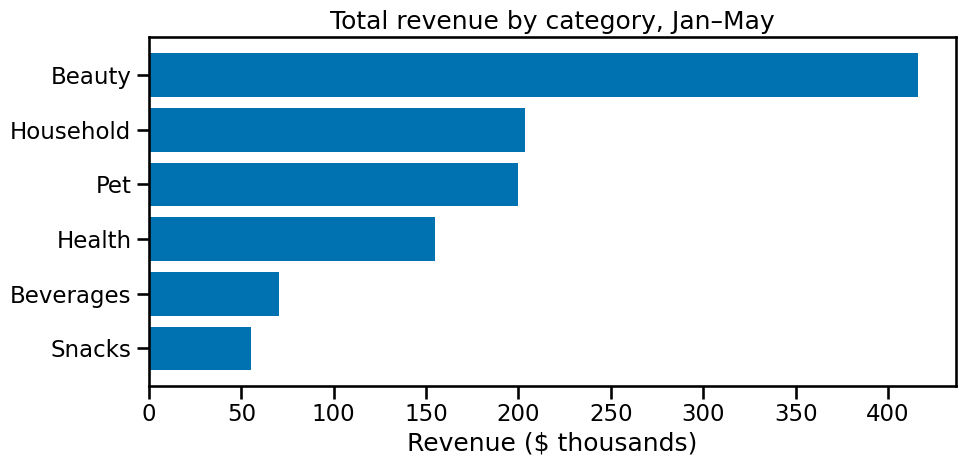

In [12]:
category_revenue = retail.pivot_table(index="category", values="revenue", aggfunc="sum")["revenue"].sort_values()

plt.figure(figsize=(10, 5))
plt.barh(category_revenue.index, category_revenue / 1000, color="#0072B2")
plt.title("Total revenue by category, Jan–May")
plt.xlabel("Revenue ($ thousands)")
plt.tight_layout()
plt.show()

Modify the chart to highlight its main message: Beauty has 7.5 times the total revenue of Snacks. Use orange for these two categories and gray for the others, and state the comparison in the title.

This chart compares total revenue. The 8.6× comparison in section 1.8 uses average margin per sales record.

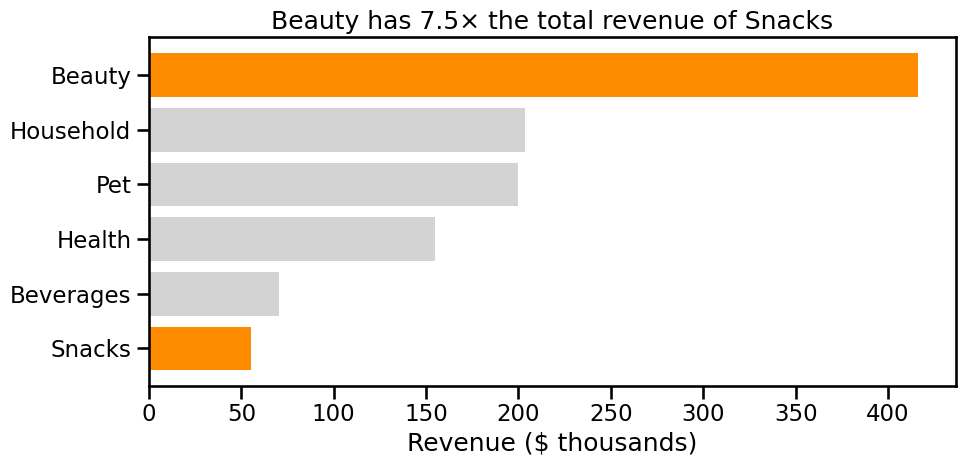

In [13]:
revenue_ratio = category_revenue["Beauty"] / category_revenue["Snacks"]
colors = ["darkorange" if category in ["Beauty", "Snacks"] else "lightgrey" for category in category_revenue.index]

plt.figure(figsize=(10, 5))
plt.barh(category_revenue.index, category_revenue / 1000, color=colors)
plt.title(f"Beauty has {revenue_ratio:.1f}× the total revenue of Snacks")
plt.xlabel("Revenue ($ thousands)")
plt.tight_layout()
plt.show()

The next chart shows a percentage: the online share of revenue by region. Build a revenue table by region and channel, then divide online revenue by each region's total and multiply by 100.

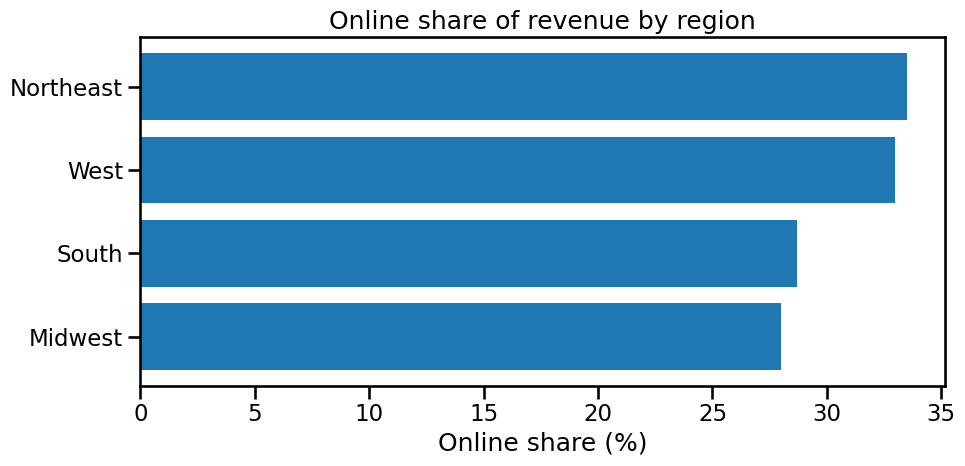

In [14]:
region_revenue = retail.pivot_table(index="region", columns="channel", values="revenue", aggfunc="sum")
online_share = (100 * region_revenue["Online"] / region_revenue.sum(axis=1)).sort_values()

plt.figure(figsize=(10, 5))
plt.barh(online_share.index, online_share)
plt.title("Online share of revenue by region")
plt.xlabel("Online share (%)")
plt.tight_layout()
plt.show()

Beauty alone brings $416k, 38% of all revenue. About a third of revenue comes from online sales in the Northeast and the West, under 30% in the South and the Midwest.

## 1.6 Two-way pivot tables and charts

With `margins=True`, `pivot_table` adds a total at the end of each row and each column. The `Total` column is the one-way table of revenue by region again, and the `Total` row is the one-way table of revenue by channel; the corner cell is all revenue.

In [15]:
region_channel = retail.pivot_table(index="region", columns="channel", values="revenue",
                                    aggfunc="sum", margins=True, margins_name="Total")
region_channel.round(0)

channel,In-Store,Online,Total
region,,,
Midwest,132766.0,51631.0,184398.0
Northeast,303445.0,152821.0,456267.0
South,176376.0,70948.0,247324.0
West,142235.0,70034.0,212269.0
Total,754822.0,345435.0,1100257.0


Drop the totals before plotting: a total drawn as one more bar or line would be compared with its own parts. Sort the regions by their total revenue.

Two charts are common for a two-way table:

- **grouped bars** compare the channels inside each region;
- **lines** show the trend when one grouping variable is time (the week × channel table from section 1.2).

A pivot table can draw itself: `.plot()` on the table draws one group of bars, or one point on each line, per row, and one color per column, with a legend.

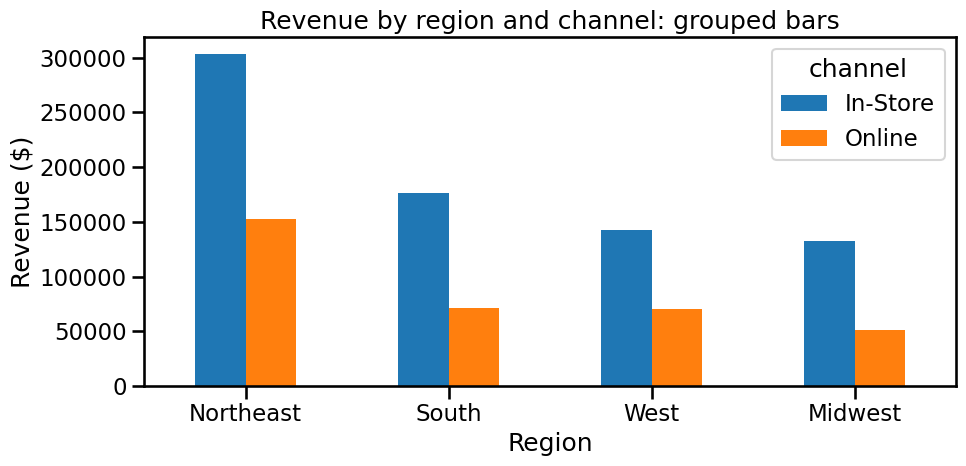

In [16]:
region_table = region_channel.drop(index="Total").sort_values("Total", ascending=False)
channels = ["In-Store", "Online"]

region_table[channels].plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Revenue by region and channel: grouped bars")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

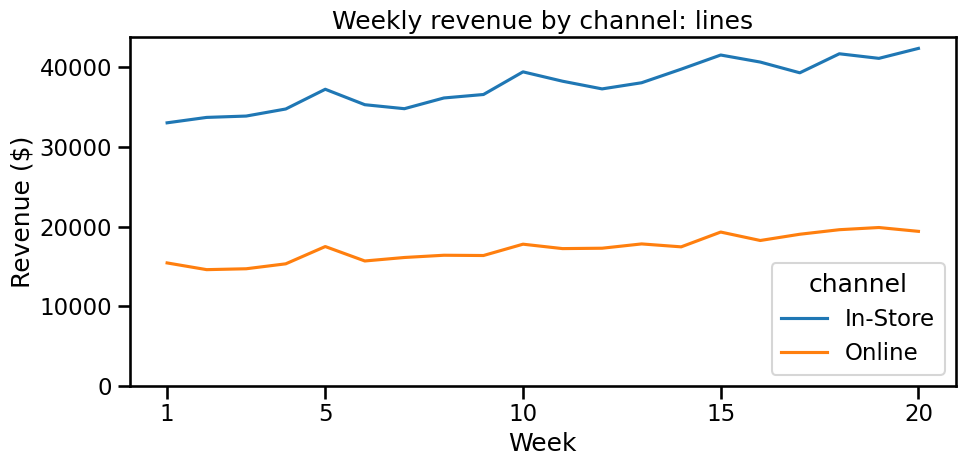

In [17]:
week_channel.plot(figsize=(10, 5))
plt.title("Weekly revenue by channel: lines")
plt.xlabel("Week")
plt.xticks([1, 5, 10, 15, 20])
plt.ylabel("Revenue ($)")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

A third chart stacks the channels: each bar is a region's total, split into its channels. Stacked bars show the totals well, but only the bottom segment starts at zero, so the online segments are hard to compare.

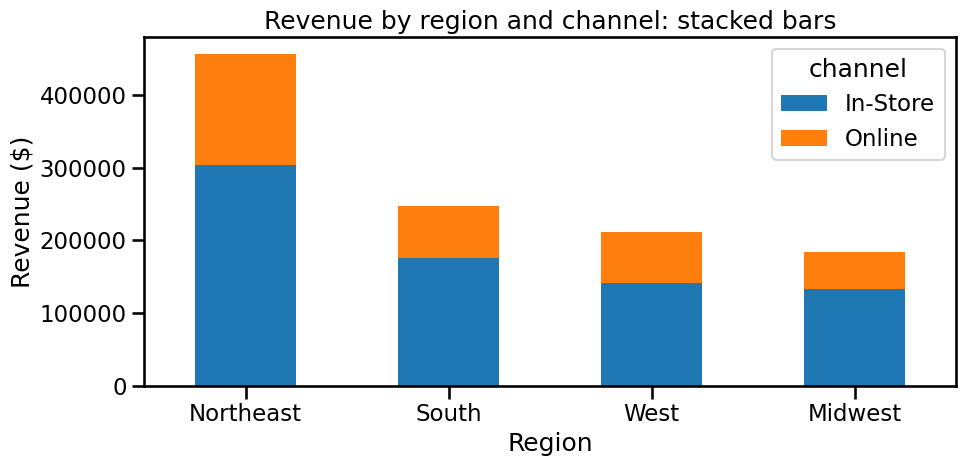

In [18]:
region_table[channels].plot(kind="bar", stacked=True, figsize=(10, 5), rot=0)
plt.title("Revenue by region and channel: stacked bars")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

## 1.7 A three-way table: region × week × channel

Three grouping variables are hard to show in one chart. One way is to split the data by one variable and draw one chart per group. Here the split is by channel: one chart for in-store revenue and one for online revenue, each with weekly revenue by region.

### Filter rows with a condition

In the dataset, the variable `channel` is either `In-Store` or `Online`. We would like to generate a pivot table for all in-store sales records, and one for all online sales records.

`retail["channel"] == "In-Store"` compares every row's channel with `"In-Store"` and returns a column of `True` and `False`, one value per row. Put this condition inside `retail[...]` to keep only the rows where it is `True`. So `in_store = retail[retail["channel"] == "In-Store"]` stores only the in-store sales records.

Similarly, `online = retail[retail["channel"] == "Online"]` stores only the online sales records.

### In-Store

Create the two-way revenue table by week and by region, for **only in-store sales records.**

In [19]:
in_store = retail[retail["channel"] == "In-Store"]
in_store_weeks = in_store.pivot_table(index="week", columns="region", values="revenue", aggfunc="sum")
in_store_weeks.round(0).head()

region,Midwest,Northeast,South,West
week,,,,
1,5922.0,13376.0,7719.0,6010.0
2,6045.0,14509.0,7388.0,5762.0
3,5950.0,13967.0,7648.0,6308.0
4,5865.0,13766.0,8155.0,6975.0
5,6889.0,14452.0,9035.0,6861.0


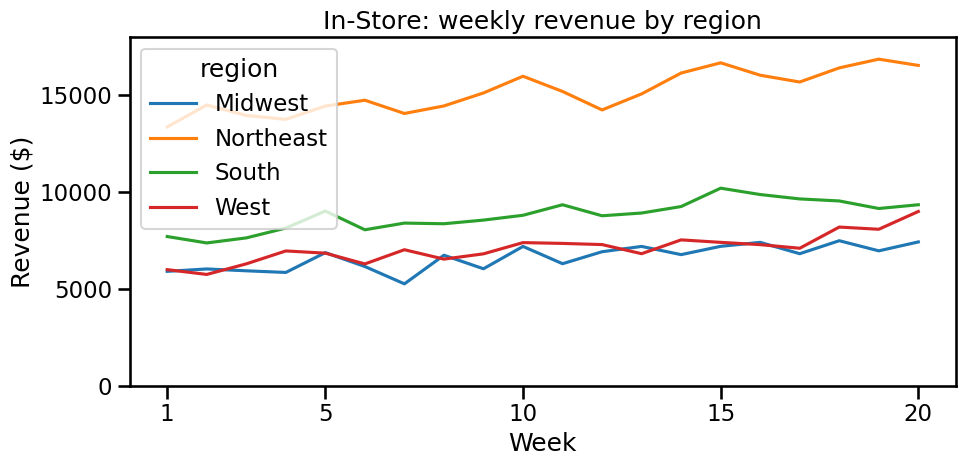

In [20]:
in_store_weeks.plot(figsize=(10, 5))
plt.title("In-Store: weekly revenue by region")
plt.xlabel("Week")
plt.xticks([1, 5, 10, 15, 20])
plt.ylabel("Revenue ($)")
plt.ylim(0, 18000)
plt.tight_layout()
plt.show()

### Online

Create the two-way revenue table by week and by region, for **only online sales records.**

In [21]:
online = retail[retail["channel"] == "Online"]
online_weeks = online.pivot_table(index="week", columns="region", values="revenue", aggfunc="sum")
online_weeks.round(0).head()

region,Midwest,Northeast,South,West
week,,,,
1,2296.0,6834.0,3327.0,2993.0
2,2070.0,6339.0,3321.0,2876.0
3,2239.0,6077.0,3149.0,3251.0
4,2274.0,6700.0,3188.0,3175.0
5,2714.0,8410.0,3253.0,3127.0


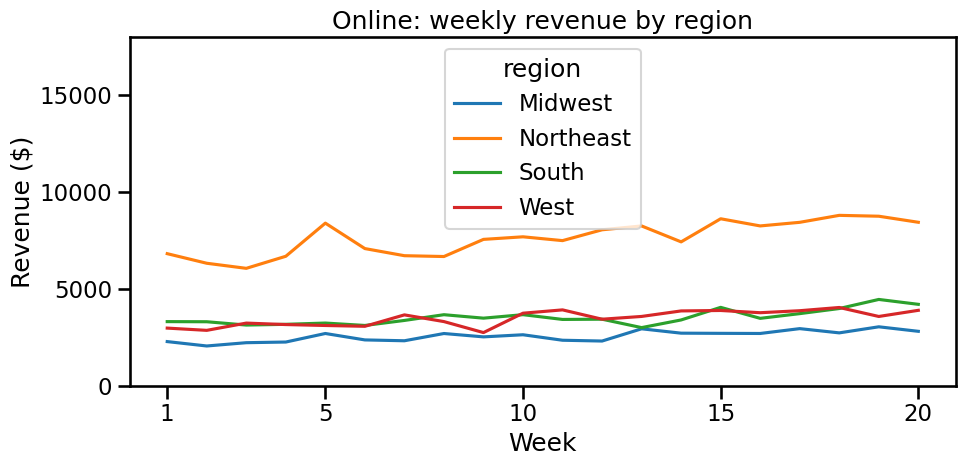

In [22]:
online_weeks.plot(figsize=(10, 5))
plt.title("Online: weekly revenue by region")
plt.xlabel("Week")
plt.xticks([1, 5, 10, 15, 20])
plt.ylabel("Revenue ($)")
plt.ylim(0, 18000)
plt.tight_layout()
plt.show()

On the same axis, every online line sits below its in-store line. In both channels the Northeast leads every week, well ahead of the South, the next region: on average 1.7 times its weekly revenue in store and 2.2 times online. In store, the South stays above the West in all 20 weeks; online, the two are close and swap places from week to week.

## 1.8 From exploration to presentation

While you explore, quick charts with the default look are enough. Once you know the message, rebuild the chart for your audience: rank the categories, highlight the comparison, and state the message in the title.

The table shows average margin per sales record for each category. Each row of data receives equal weight, regardless of the number of units sold.

In [23]:
category_margin = retail.groupby("category").agg(margin_per_record=("margin", "mean"))
category_margin.round(2)

,margin_per_record
category,
Beauty,10.47
Beverages,1.22
Health,5.81
Household,4.28
Pet,5.87
Snacks,1.80


The first chart is the exploration version: the categories in the table's alphabetical order, the default look and a generic title.

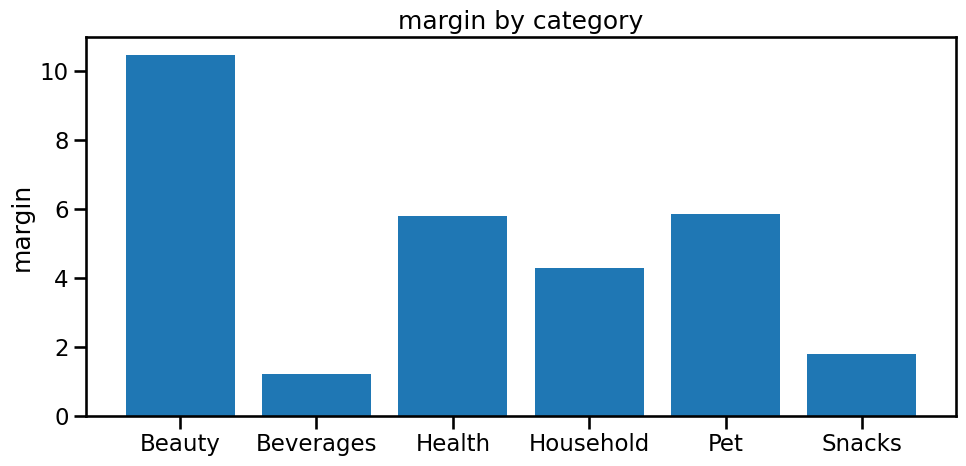

In [24]:
plt.figure(figsize=(10, 5))
plt.bar(category_margin.index, category_margin["margin_per_record"])
plt.title("margin by category")
plt.ylabel("margin")
plt.tight_layout()
plt.show()

The second chart is the presentation version. The bars are ranked, the title states the message, and color marks the two categories the message compares. Here the colors carry the message, so the code sets them: a list gives each bar its own color.

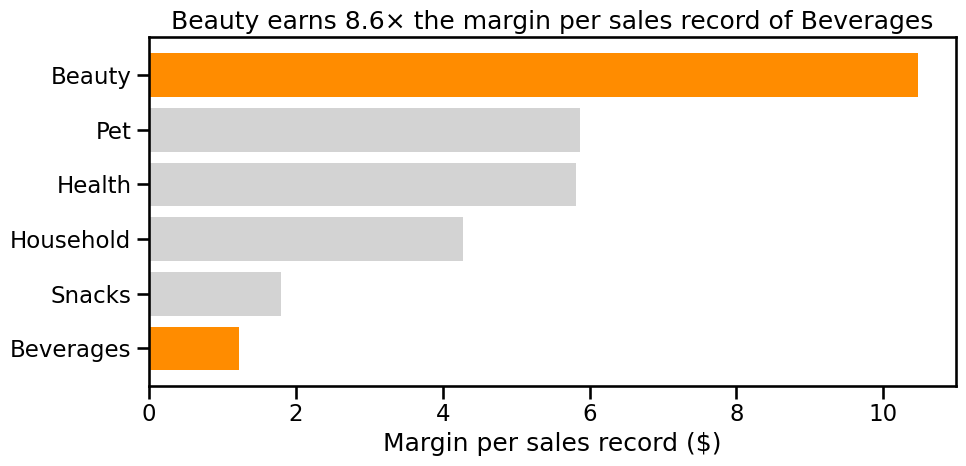

In [25]:
ranked = category_margin["margin_per_record"].sort_values()
ratio = ranked["Beauty"] / ranked["Beverages"]
colors = ["darkorange" if category in ["Beauty", "Beverages"] else "lightgrey" for category in ranked.index]

plt.figure(figsize=(10, 5))
plt.barh(ranked.index, ranked, color=colors)
plt.title(f"Beauty earns {ratio:.1f}× the margin per sales record of Beverages")
plt.xlabel("Margin per sales record ($)")
plt.tight_layout()
plt.show()

Beauty earns $10.47 of margin per sales record, 8.6 times the $1.22 of Beverages.

## Exercise: store performance

Work on your own with `retail`, which is already loaded. The worked examples above looked at revenue; this exercise looks at **margin**, which is revenue minus cost.

Write your code in the empty code cells and your answers in the text cells below them.

### Question 1

Generate a pivot table and a chart to answer: what is the total margin of each store, and which three stores have the highest total margin?



**(a)** Which pivot table answers this question: one-way or two-way, and grouped by which variable? What do you put in each argument of `pivot_table`: `index`, `columns`, `values` and `aggfunc`?

*Your answer:*

**(b)** Build the pivot table from `retail` and sort it from the highest to the lowest total margin. Then draw a bar chart of total margin by store, in the same order. Which three stores have the highest total margin?

*Your answer:*

**(c)** Draw the chart again, with the three highest-margin stores in one color and the other stores in gray. Give the chart a title that states its message. Create a list `top3` with the three top `store_id` values. (You can give each bar its own color as in sections 1.5 and 1.8.)

*Your answer:*

### Question 2

How does weekly margin change for store 14, the store with the highest total margin? Use a filter to keep store 14's rows of `retail` (section 1.7), build a pivot table of its total margin by week, and add a line chart. In which week is its margin highest?

*Your answer:*